# ShopSmart AI — Exploratory Data Analysis

**Objective:** Understand the Flipkart product review dataset before building ML models.

**Dataset:** `data/flipkart_product_review.csv` — 450 product reviews across 9 audio products.

**Columns:** `product_id`, `product_title`, `rating`, `summary`, `review`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Style setup
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Data Loading & First Look

In [2]:
df = pd.read_csv('../data/flipkart_product_review.csv')
prices = pd.read_csv('../data/product_prices.csv')

# Merge price data
df = df.merge(prices, on='product_title', how='left')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
df.head()

Dataset shape: (450, 6)
Columns: ['product_id', 'product_title', 'rating', 'summary', 'review', 'price']



,product_id,product_title,rating,summary,review,price
0,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,1-more flexible2-bass is very high3-sound clar...,999
1,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Super sound and good looking I like that prize,999
2,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,Very much satisfied with the device at this pr...,999
3,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Super!,"Nice headphone, bass was very good and sound i...",999
4,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,5,Terrific purchase,Sound quality super battery backup super quali...,999


In [3]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     450 non-null    object
 1   product_title  450 non-null    object
 2   rating         450 non-null    int64 
 3   summary        450 non-null    object
 4   review         450 non-null    object
 5   price          450 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 21.2+ KB


In [4]:
# Basic statistics
df.describe(include='all')

,product_id,product_title,rating,summary,review,price
count,450,450,450.000000,450,450,450.000000
unique,9,9,NaN,50,449,NaN
top,ACCFZGAQJGYCYDCM,BoAt Rockerz 235v2 with ASAP charging Version ...,NaN,Wonderful,Good,NaN
freq,50,50,NaN,23,2,NaN
mean,NaN,NaN,4.402222,NaN,NaN,1293.444444
std,NaN,NaN,1.076369,NaN,NaN,664.249516
min,NaN,NaN,1.000000,NaN,NaN,449.000000
25%,NaN,NaN,4.000000,NaN,NaN,599.000000
50%,NaN,NaN,5.000000,NaN,NaN,1299.000000
75%,NaN,NaN,5.000000,NaN,NaN,1999.000000


## 2. Data Quality Assessment

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("=== Missing Values ===")
print(quality_df)
print()

# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate reviews (same review text): {df['review'].duplicated().sum()}")
print()

# Empty reviews
empty_reviews = df['review'].apply(lambda x: len(str(x).strip()) == 0).sum()
print(f"Empty/blank reviews: {empty_reviews}")

=== Missing Values ===
               Missing Count  Missing %
product_id                 0        0.0
product_title              0        0.0
rating                     0        0.0
summary                    0        0.0
review                     0        0.0
price                      0        0.0

Duplicate rows: 0
Duplicate reviews (same review text): 1

Empty/blank reviews: 0


In [6]:
# Unique values per column
print("=== Unique Values ===")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()}")

print(f"\nUnique products: {df['product_title'].nunique()}")
print(f"Reviews per product: {len(df) // df['product_title'].nunique()}")

=== Unique Values ===
  product_id: 9
  product_title: 9
  rating: 5
  summary: 50
  review: 449
  price: 8

Unique products: 9
Reviews per product: 50


## 3. Rating Distribution Analysis

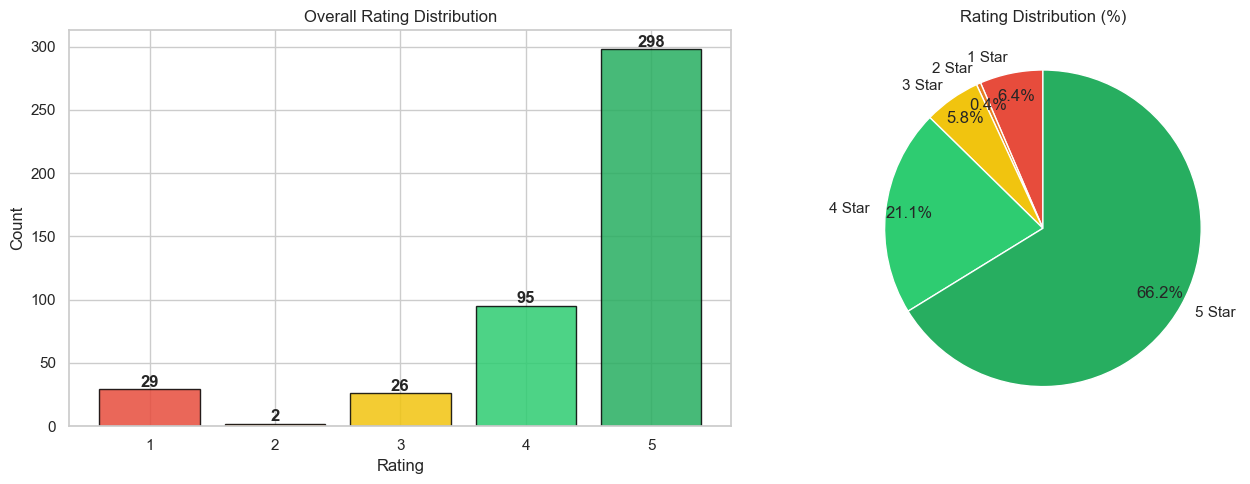


Mean rating: 4.40
Median rating: 5.0
Rating std: 1.08


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall rating distribution
rating_counts = df['rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Add count labels on bars
for i, (rating, count) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(rating, count + 2, str(count), ha='center', fontweight='bold')

# Rating as pie chart
axes[1].pie(rating_counts.values, labels=[f'{r} Star' for r in rating_counts.index],
            colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
axes[1].set_title('Rating Distribution (%)')

plt.tight_layout()
plt.savefig('../notebooks/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean rating: {df['rating'].mean():.2f}")
print(f"Median rating: {df['rating'].median():.1f}")
print(f"Rating std: {df['rating'].std():.2f}")

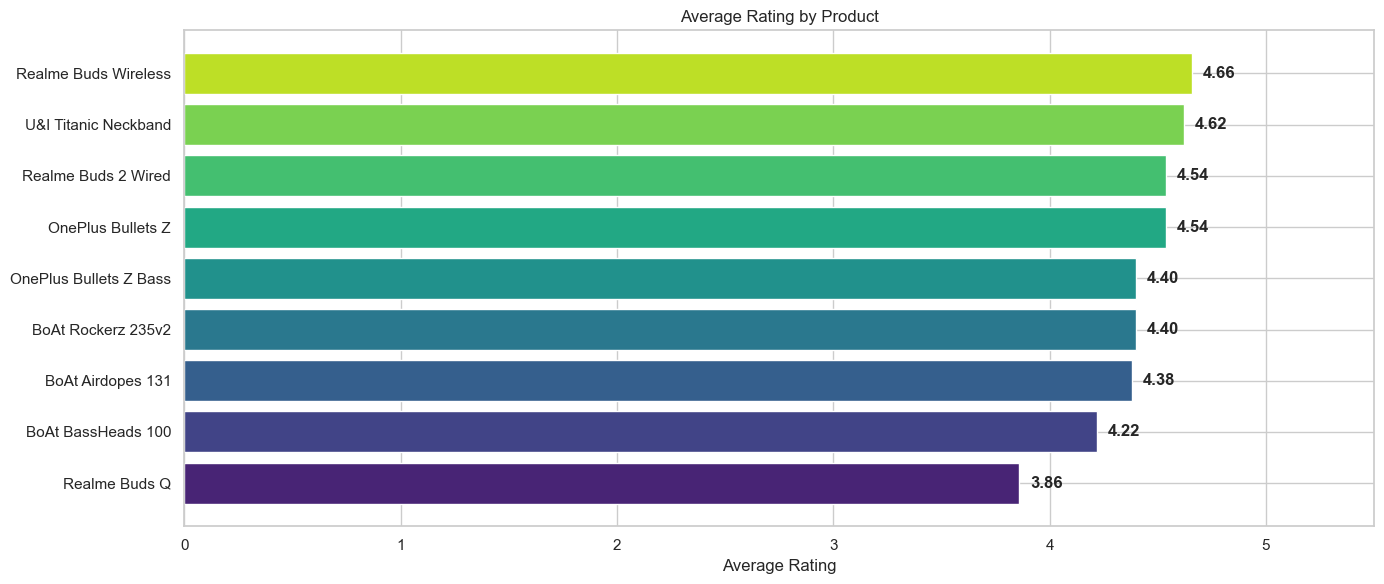

In [8]:
# Rating distribution per product
fig, ax = plt.subplots(figsize=(14, 6))

# Shorter product names for readability
short_names = {
    'BoAt Rockerz 235v2 with ASAP charging Version 5.0 Bluetooth Headset': 'BoAt Rockerz 235v2',
    'realme Buds Wireless Bluetooth Headset': 'Realme Buds Wireless',
    'OnePlus Bullets Wireless Z Bluetooth Headset': 'OnePlus Bullets Z',
    'realme Buds 2 Wired Headset': 'Realme Buds 2 Wired',
    'OnePlus Bullets Wireless Z Bass Edition Bluetooth Headset': 'OnePlus Bullets Z Bass',
    'realme Buds Q Bluetooth Headset': 'Realme Buds Q',
    'U&I Titanic Series - Low Price Bluetooth Neckband Bluetooth Headset': 'U&I Titanic Neckband',
    'BoAt Airdopes 131 Bluetooth Headset': 'BoAt Airdopes 131',
    'BoAt BassHeads 100 Wired Headset': 'BoAt BassHeads 100'
}
df['product_short'] = df['product_title'].map(short_names)

product_ratings = df.groupby('product_short')['rating'].mean().sort_values(ascending=True)
bars = ax.barh(product_ratings.index, product_ratings.values, color=sns.color_palette('viridis', len(product_ratings)))
ax.set_xlabel('Average Rating')
ax.set_title('Average Rating by Product')
ax.set_xlim(0, 5.5)

# Add value labels
for bar, val in zip(bars, product_ratings.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/rating_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Review Length Analysis

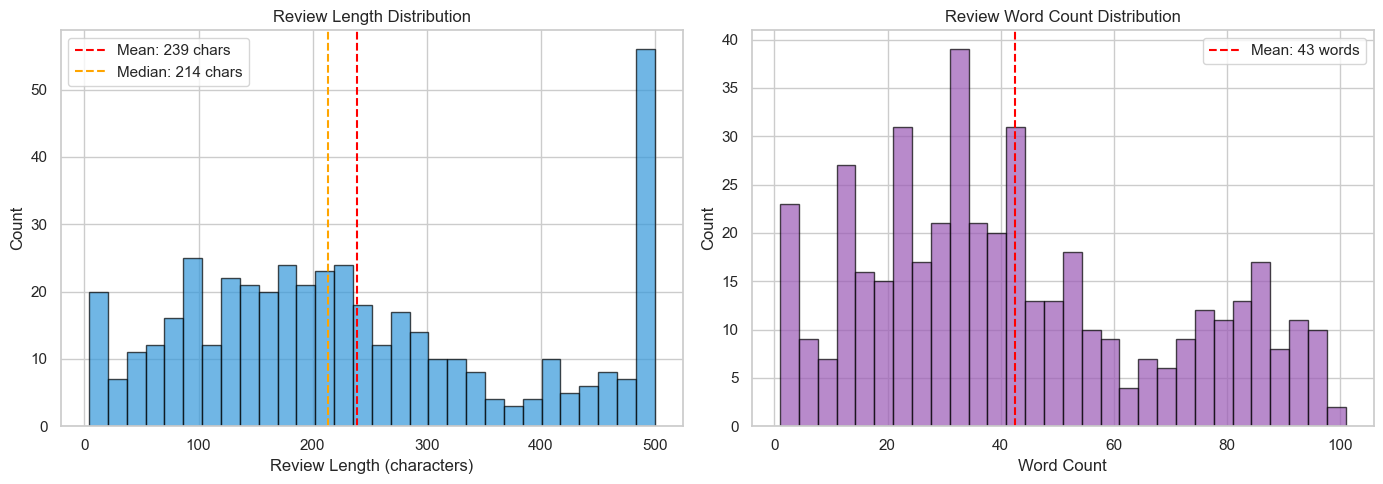

Review length stats:
  Min: 4 chars | Max: 500 chars
  Mean: 239 chars | Median: 214 chars
  Very short reviews (<20 chars): 19


In [9]:
# Add text length features
df['review_length'] = df['review'].astype(str).apply(len)
df['review_word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))
df['summary_length'] = df['summary'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review length distribution
axes[0].hist(df['review_length'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(df['review_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['review_length'].mean():.0f} chars")
axes[0].axvline(df['review_length'].median(), color='orange', linestyle='--', label=f"Median: {df['review_length'].median():.0f} chars")
axes[0].set_xlabel('Review Length (characters)')
axes[0].set_ylabel('Count')
axes[0].set_title('Review Length Distribution')
axes[0].legend()

# Word count distribution
axes[1].hist(df['review_word_count'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].axvline(df['review_word_count'].mean(), color='red', linestyle='--', label=f"Mean: {df['review_word_count'].mean():.0f} words")
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].set_title('Review Word Count Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Review length stats:")
print(f"  Min: {df['review_length'].min()} chars | Max: {df['review_length'].max()} chars")
print(f"  Mean: {df['review_length'].mean():.0f} chars | Median: {df['review_length'].median():.0f} chars")
print(f"  Very short reviews (<20 chars): {(df['review_length'] < 20).sum()}")

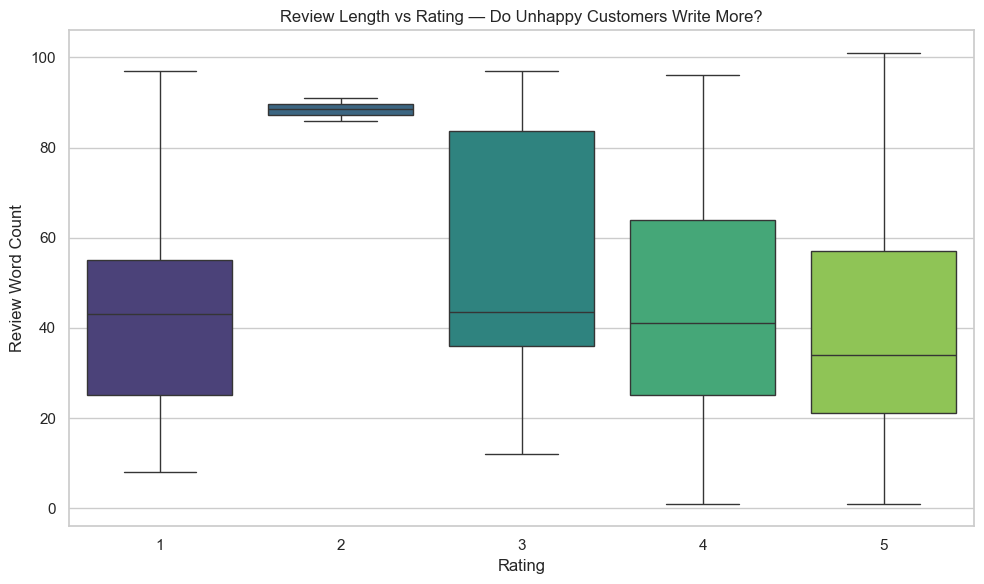


Average word count by rating:
rating
1    44.4
2    88.5
3    55.8
4    43.5
5    40.6


In [10]:
# Review length vs Rating — do unhappy customers write longer reviews?
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='rating', y='review_word_count', palette='viridis', ax=ax)
ax.set_xlabel('Rating')
ax.set_ylabel('Review Word Count')
ax.set_title('Review Length vs Rating — Do Unhappy Customers Write More?')
plt.tight_layout()
plt.savefig('../notebooks/length_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# Average word count per rating
print("\nAverage word count by rating:")
print(df.groupby('rating')['review_word_count'].mean().round(1).to_string())

## 5. Price Analysis

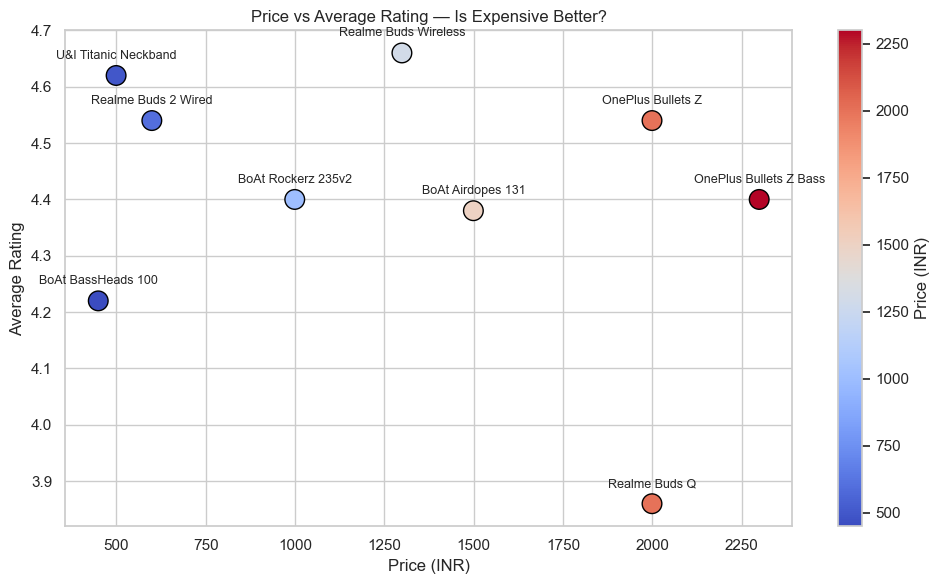


Correlation between price and avg rating: -0.294


In [11]:
# Price vs Average Rating
price_rating = df.groupby('product_short').agg(
    avg_rating=('rating', 'mean'),
    price=('price', 'first')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(price_rating['price'], price_rating['avg_rating'], 
                     s=200, c=price_rating['price'], cmap='coolwarm', 
                     edgecolor='black', zorder=5)

for _, row in price_rating.iterrows():
    ax.annotate(row['product_short'], (row['price'], row['avg_rating']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)

ax.set_xlabel('Price (INR)')
ax.set_ylabel('Average Rating')
ax.set_title('Price vs Average Rating — Is Expensive Better?')
plt.colorbar(scatter, label='Price (INR)')
plt.tight_layout()
plt.savefig('../notebooks/price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
corr = price_rating['price'].corr(price_rating['avg_rating'])
print(f"\nCorrelation between price and avg rating: {corr:.3f}")

## 6. Word Cloud & Text Patterns

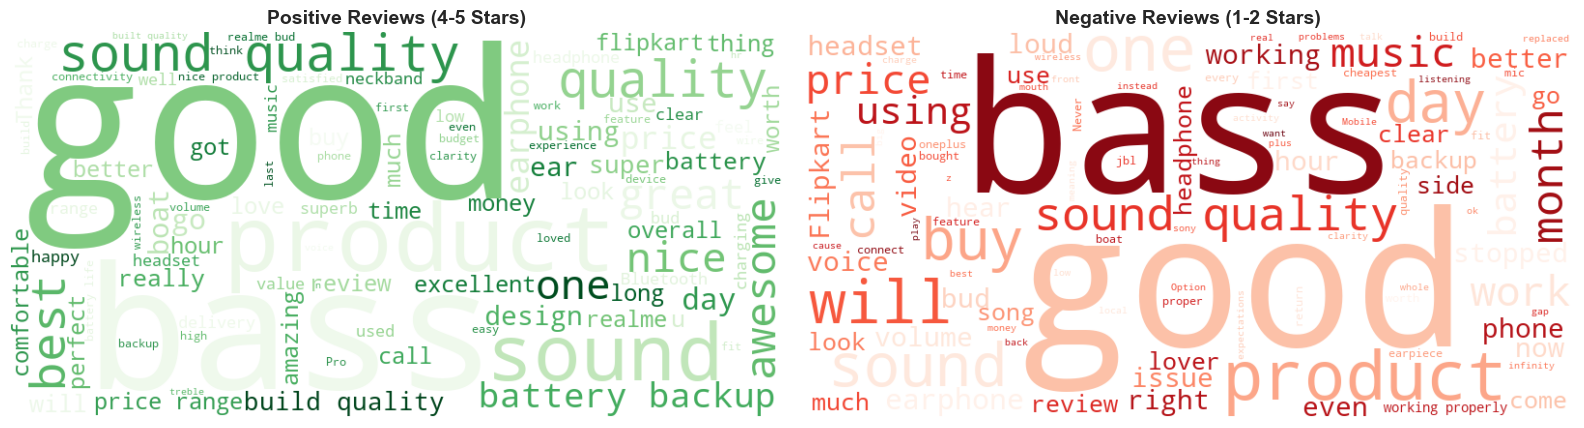

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive reviews word cloud (4-5 stars)
positive_text = ' '.join(df[df['rating'] >= 4]['review'].astype(str))
wc_pos = WordCloud(width=800, height=400, background_color='white', 
                   colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews (4-5 Stars)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Negative reviews word cloud (1-2 stars)
negative_text = ' '.join(df[df['rating'] <= 2]['review'].astype(str))
wc_neg = WordCloud(width=800, height=400, background_color='white', 
                   colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews (1-2 Stars)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../notebooks/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

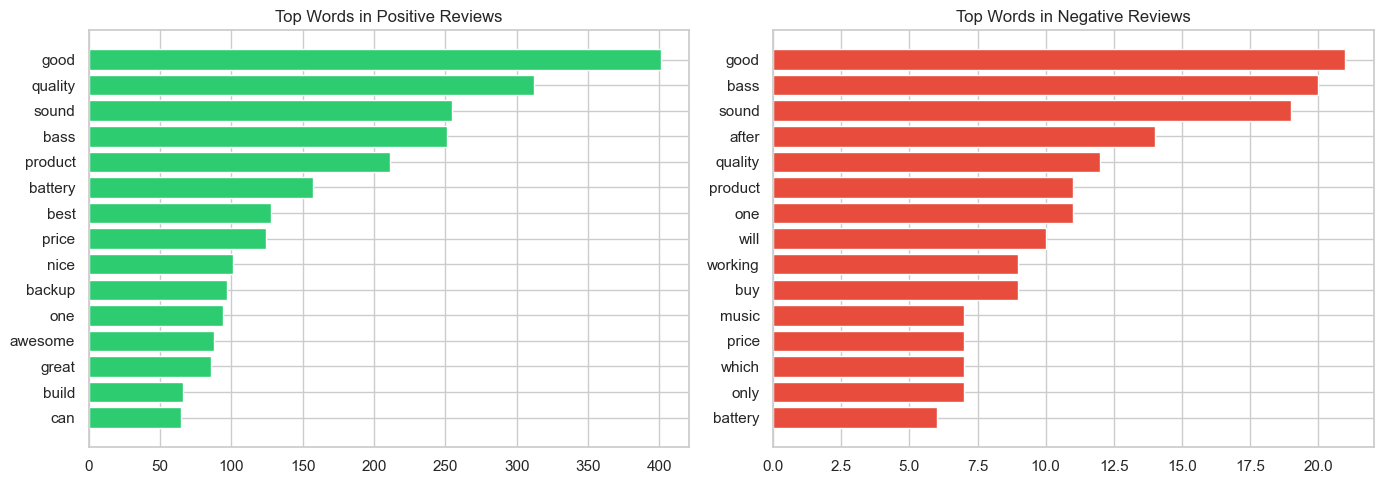

In [13]:
# Most common words in positive vs negative reviews
from collections import Counter
import re

def get_top_words(texts, n=15):
    """Get top n most frequent words, excluding common stop words."""
    stop_words = {'the', 'a', 'an', 'is', 'it', 'in', 'to', 'and', 'of', 'for', 
                  'i', 'this', 'that', 'was', 'with', 'but', 'not', 'are', 'on',
                  'my', 'its', 'very', 'at', 'be', 'as', 'so', 'you', 'have',
                  'from', 'or', 'me', 'all', 'just', 'also', 'no', 'has', 'had'}
    words = re.findall(r'\b[a-z]+\b', ' '.join(texts).lower())
    filtered = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(filtered).most_common(n)

pos_words = get_top_words(df[df['rating'] >= 4]['review'].astype(str))
neg_words = get_top_words(df[df['rating'] <= 2]['review'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([w[0] for w in pos_words][::-1], [w[1] for w in pos_words][::-1], color='#2ecc71')
axes[0].set_title('Top Words in Positive Reviews')

axes[1].barh([w[0] for w in neg_words][::-1], [w[1] for w in neg_words][::-1], color='#e74c3c')
axes[1].set_title('Top Words in Negative Reviews')

plt.tight_layout()
plt.savefig('../notebooks/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sentiment Label Distribution (for ML Model)

We'll use ratings as sentiment proxy labels for the sentiment model in the next phase:
- **Negative**: Rating 1-2
- **Neutral**: Rating 3
- **Positive**: Rating 4-5

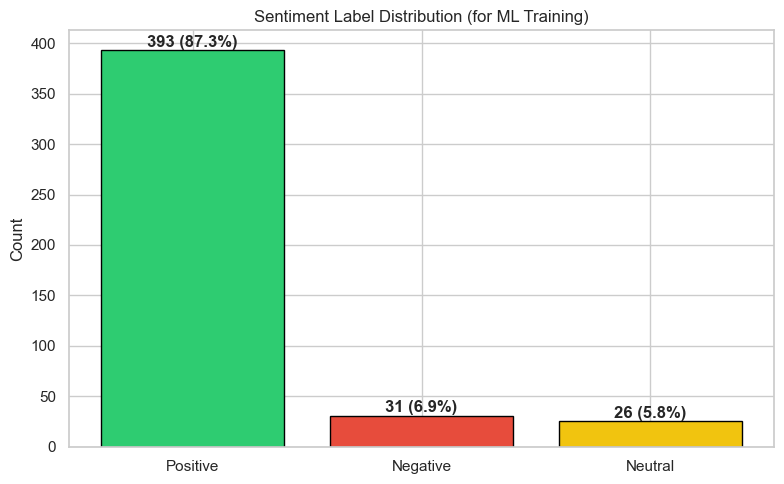


=== Class Balance ===
sentiment
Positive    393
Negative     31
Neutral      26

Imbalance ratio (Positive/Negative): 12.7x

Note: If heavily imbalanced, we may need stratified sampling or class weights during training.


In [14]:
# Create sentiment labels
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

# Distribution
sent_counts = df['sentiment'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
colors_sent = {'Positive': '#2ecc71', 'Neutral': '#f1c40f', 'Negative': '#e74c3c'}
bars = ax.bar(sent_counts.index, sent_counts.values, 
              color=[colors_sent[s] for s in sent_counts.index], edgecolor='black')

for bar, val in zip(bars, sent_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3, 
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

ax.set_ylabel('Count')
ax.set_title('Sentiment Label Distribution (for ML Training)')
plt.tight_layout()
plt.savefig('../notebooks/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Class Balance ===")
print(sent_counts.to_string())
print(f"\nImbalance ratio (Positive/Negative): {sent_counts.get('Positive', 0) / max(sent_counts.get('Negative', 1), 1):.1f}x")
print("\nNote: If heavily imbalanced, we may need stratified sampling or class weights during training.")

## 8. Key Findings & Recommendations

### Data Quality
- **450 reviews** across **9 audio products** (50 reviews each — perfectly balanced by product)
- Check for missing/duplicate values above
- Very short reviews may not carry useful signal for sentiment analysis

### Insights for ML
- **Class imbalance**: Positive reviews likely dominate (common on e-commerce). Need stratified splits.
- **Review length varies widely**: Consider length-based features or filtering very short reviews.
- **Word patterns differ** between positive and negative reviews — good signal for classification.

### Next Steps
1. **Data cleaning**: Handle NaN, remove very short reviews, normalize text
2. **Sentiment model**: Train using rating as proxy label (TF-IDF baseline, then DistilBERT)
3. **Integration**: Add sentiment predictions to the chatbot responses